In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import ttest_ind
from tqdm.auto import tqdm

In [2]:
df = pd.read_csv('train_data.csv')
df

,2019-01-01,2019-01-02,2019-01-03,2019-01-04,2019-01-05,2019-01-06,2019-01-07,2019-01-08,2019-01-09,2019-01-10,...,2020-12-21,2020-12-22,2020-12-23,2020-12-24,2020-12-25,2020-12-26,2020-12-27,2020-12-28,2020-12-29,2020-12-30
0,-3.533155,-4.475755,-4.748074,-5.569953,-8.017896,-12.396771,-11.853961,-12.046498,-10.297042,-10.075553,...,-168.163849,-168.728405,-168.971555,-168.824042,-167.700081,-167.634364,-167.856116,-168.743465,-168.231590,-167.913551
1,-3.824475,-1.530769,0.038338,-1.475237,-1.602029,-0.992509,0.302906,1.789140,4.177589,9.273372,...,75.919063,72.909418,75.289867,77.770907,74.099941,72.411474,67.472791,67.084800,66.805609,72.078232
2,-1.616434,-4.658834,-6.746498,-9.979424,-11.683396,-9.507703,-7.614438,-9.735666,-10.754863,-11.058539,...,47.759469,46.596598,50.135737,48.424880,47.740658,46.676116,45.611939,43.331310,45.655325,39.770838
3,-0.157282,1.827617,-2.585284,-4.397189,0.113494,7.614615,5.456654,5.928451,6.953534,4.514409,...,318.364962,319.281629,322.614999,325.200268,324.745069,326.519830,326.467326,321.806523,321.286907,323.570847
4,2.056969,10.187929,8.559520,8.579555,9.464262,9.038088,10.875990,9.883777,8.026472,13.040411,...,-38.079584,-38.515039,-38.031876,-36.610698,-37.753387,-35.470938,-35.454435,-35.026979,-35.633306,-35.460477
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,-3.587807,-3.483476,-5.662556,-3.837491,-5.530929,-9.273811,-11.937906,-14.508804,-14.150711,-14.562552,...,-741.363369,-741.022973,-741.129730,-742.161579,-742.406547,-744.432050,-744.743253,-745.921464,-746.156278,-746.277952
49996,-0.380924,-2.764911,-1.806310,-1.504112,-0.716610,-1.032476,0.261067,0.698457,1.761118,2.989615,...,-105.893100,-104.987557,-105.008367,-106.021453,-105.188027,-106.482869,-105.304146,-106.512414,-104.768522,-105.871369
49997,5.238142,2.849922,2.889722,4.794517,3.693688,1.836000,2.844668,3.958795,3.108119,3.574019,...,-243.925622,-243.997646,-246.100857,-248.317254,-248.064941,-247.333195,-248.392125,-240.174788,-238.412495,-239.414134
49998,-1.019643,-1.218311,-1.865265,-3.136355,-6.201435,-5.453041,-6.738012,-1.265761,-0.757471,-3.450860,...,980.226549,981.486257,980.363861,980.776530,980.699069,979.576181,984.177939,983.178530,976.018038,979.440915


# Условие

**В этом домашнем задании вы должны написать свою сплит систему для проведения A/B тестов**

В предоставленных данных есть 50000 юзеров, для каждого есть запись какой-то метрики за 2 года (730 дней). 

Данные: https://disk.yandex.ru/d/2mH8fuKCKLeozg


### Ваша задача:

1) Написать алгоритм, которые разбивает данные на 3 группы размера около 5000, которые будут считаться "похожими".

- Для этого вам самостоятельно нужно решить, какие критерии схожести тут применимы и построить необходимые тесты для выбора этих групп.

- Данные 3 группы должны считаться похожими на основе ваших метрик. 

- Разбиение затем будет протестировано на следующих 2х годах нами. 

2) Визуализировать распределения выбранных вами метрик для найденных групп и сравнить с аналогичными разультатами для случайных групп

### Нужно реализовать следующие функции (вы можете добавлять какие-то побочные, если считаете нужным): 

`generate_groups`  - функция, которая по данным и числу групп делает случайное разбиение данных на примерно одинаковые части по количеству групп

`conduct_test_on_pair` - функция проводит статистические тесты между двумя данными группами и возвращает нужные статистики и результаты

`conduct_tests` -- по списку групп и количеству необходимых похожих групп (зафиксировано в условии задачи как 3) перебирает возможные тройки групп пока не найдет похожие, критерий остановки за вами

`find_groups` -- берет данные и число групп, на которое вы их разбиваете и ищет 3 группы удовлетворяющие вашим критериям схожести.

Рекомендуем начинать с того, чтобы искать разбиение на 2 группы, а не 3, чтобы проверить, что сплит система работает адекватно. Задача с двумя группами зачастую сильно проще, чем с тремя.

Группы должны состоять из уникальных клиентов без дубликатов, один клиент может быть только в одной группе. То есть должны выбирать группы из датасета без повторений и у групп не должно быть пересечений.

 Про то, по каким параметрам оценивать группы: в этом задании вам требуется найти группы, в которых распределения **средних значений и дисперсии данной последовательности** по пользователям похожи. То есть вам нужно вычислить среднее значение и дисперсию данной последовательности для каждого пользователя, а затем проверить, что распределения результатов между группами схожи по вашим тестам.


**Замечание**: Для разбиения на группы и сравнения похожести можете брать любую метрику и считать любой критерии, но мы будем сравнивать именно метрику «среднее» и дисперсию на следующих по времени данных

#### Про систему оценивания: При оценивании мы будем проверять полученные вами группы как на этих данных, так и на следующих двух годах. При проверке будем учитывать и качество полученных групп при помощи метрик. 

## Напишите следующие функции

In [3]:
def generate_groups(df, group_num):
    """
    Splits users into group_num groups of similar size
    
    df : Dataframe with all user data, can be pandas, numpy or whatever you like
    group_num : number of groups to split into
    
    returns a list of dataframes of generated groups
    """
    pass

def conduct_tests_on_pair(df_1, df_2):
    """
    Conducts statistical test or tests on two given groups to decide if they are similar
    
    df_i : Dataframe of users of a single group
    
    returns p-value or anything you need further
    """
    pass
    
def conduct_tests(dfs, group_num):
    """
    Goal is to find out if there is group_num groups in the dfs list which are similar enough according to your criterion. 
    For every (or maybe not every) selection of group_num groups from the dfs list and conducts pairwise tests on selected subset using conduct_tests_on_pair. 
    
    dfs : list of dataframes of groups
    
    returns list of selected groups or None if there are no similar groups 
    """
    pass

def find_groups(df, group_num):
    """
    Splits df imto groups and conducts tests on subsets of the groups until necessary groups are found
    """
    for i in range(100000):
        dfs = generate_groups(df, group_num)
        result = conduct_tests(dfs, 3)
        
        if result is not None:
            return result

# Сгенерим сразу 3 группы

In [4]:
def generate_groups(df, group_num):
    
    rows_per_group = 5000 #количество клиентов
    total_rows = rows_per_group * group_num
    
    if len(df) < total_rows:
        raise ValueError("В датасете недостаточно строк для генерации нужного количества групп")
    
    #рандомно выберем строки для формирования группы
    df_shuffled = df.sample(frac=1).reset_index(drop=True) 
    groups = [df_shuffled.iloc[i*rows_per_group:(i+1)*rows_per_group] for i in range(group_num)]
    return groups

groups = generate_groups(df, 3)

#вывод результатов
print(f"Сгенерировано {len(groups)} группы.")
for i, group in enumerate(groups):
    print(f"Группа {i+1}: пользоваталей(строк) = {len(group)}, среднее: {group.mean().mean()}")

Сгенерировано 3 группы.
Группа 1: пользоваталей(строк) = 5000, среднее: -31.51611182322647
Группа 2: пользоваталей(строк) = 5000, среднее: -151.1386246300697
Группа 3: пользоваталей(строк) = 5000, среднее: -91.2620726837145


# Посчитаем Т статистику в этих 3-ех группах

In [5]:
def conduct_tests(groups, alpha=0.05):

    results = []
    
    #Пробегаемся по всем парам групп
    for i in range(len(groups)):
        for j in range(i+1, len(groups)):
            #считаем т-тест между группами i и j
            t_stat, p_value = ttest_ind(groups[i].mean(), groups[j].mean(), equal_var=False, nan_policy='omit')
            
            #проверяем, отвергается ли нулевая гипотеза
            reject_null = p_value < alpha
            
            #добавляем результаты в список
            results.append({
                'Группы': (i+1, j+1),
                'т-статистика': t_stat,
                'p-value': p_value,
                'Ответгаем нулевую гипотезу': reject_null
            })
    
    return results

test_results = conduct_tests(groups)

#результаты
for result in test_results:
    print(f"Группы {result['Группы']}: т-статистика = {result['т-статистика']:.3f}, "
          f"p-value = {result['p-value']:.3f}, "
          f"Ответгаем нулевую гипотезу = {result['Ответгаем нулевую гипотезу']}")

Группы (1, 2): т-статистика = 28.496, p-value = 0.000, Ответгаем нулевую гипотезу = True
Группы (1, 3): т-статистика = 27.120, p-value = 0.000, Ответгаем нулевую гипотезу = True
Группы (2, 3): т-статистика = -13.190, p-value = 0.000, Ответгаем нулевую гипотезу = True


# Найдем похожие 3 группы у которых будут +/- равны средние и дисперсия

In [6]:
def find_groups(df, group_num):
    rows_per_group = 5000
    total_rows = rows_per_group * group_num
    
    if len(df) < total_rows:
        raise ValueError("В датасете недостаточно строк для генерации нужного количества групп")
    
    #инициализация лучшего разбиения и его статистики
    best_score = float('inf')
    best_groups = None
    
    #алгоритм брутфорса: генерация множества случайных разбиений и выбор лучшего из них
    for _ in tqdm(range(1000)):  #количество итераций, чем больше, тем лучше
        
        #рандомно выберем строки для формирования группы
        df_shuffled = df.sample(frac=1).reset_index(drop=True)
        groups = [df_shuffled.iloc[i*rows_per_group:(i+1)*rows_per_group] for i in range(group_num)]
        
        #считаем среднюю и дисперсию по всем группам
        group_means = np.array([group.mean().mean() for group in groups])
        group_vars = np.array([group.var().mean() for group in groups])
        
        #считаем стандартное отклонение средних значений и дисперсий между группами
        mean_std_dev = np.std(group_means)
        var_std_dev = np.std(group_vars)
        
        #смотрим на разбиение, используя сумму стандартных отклонений средних и дисперсий
        #смотрим на сумму метрик с весами
        current_score = mean_std_dev #* 3 + var_std_dev*(0.5)  
        
        #если текущее разбиение лучше предыдущего, сохраняем его
        if current_score < best_score:
            best_score = current_score
            best_groups = groups
    
    return best_groups



#генерация групп
groups = find_groups(df, 3)

#вывод результатов
print(f"Сгенерировано {len(groups)} групп.")
for i, group in enumerate(groups):
    print(f"Группа {i+1}: Среднее = {group.mean().mean()}, Дисперсия = {group.var().mean()}, Строк = {len(group)}")
    
#считаем т-статистику
    
results = []
alpha = 0.05

    #пробегаемся по всем парам групп
for i in range(len(groups)):
    for j in range(i+1, len(groups)):
            #считаем т-тест между группами i и j
        t_stat, p_value = ttest_ind(groups[i].mean(), groups[j].mean(), equal_var=False, nan_policy='omit')
            
            #проверяем, отвергается ли нулевая гипотеза
        reject_null = p_value < alpha
            
            #добавляем результаты в список
        results.append({
                'Группы': (i+1, j+1),
                'т-статистика': t_stat,
                'p-value': p_value,
                'Ответгаем нулевую гипотезу': reject_null
            })
#вывод результатов
for result in results:
    print(f"Группы {result['Группы']}: т-статистика = {result['т-статистика']:.3f}, "
          f"p-value = {result['p-value']:.3f}, "
          f"Ответгаем нулевую гипотезу = {result['Ответгаем нулевую гипотезу']}")

  0%|          | 0/1000 [00:00<?, ?it/s]

Сгенерировано 3 групп.
Группа 1: Среднее = -45.46797626280156, Дисперсия = 24533094.91681474, Строк = 5000
Группа 2: Среднее = -47.04848478062749, Дисперсия = 9801439.780041058, Строк = 5000
Группа 3: Среднее = -45.41597287561434, Дисперсия = 3960402.959617608, Строк = 5000
Группы (1, 2): т-статистика = 0.895, p-value = 0.371, Ответгаем нулевую гипотезу = False
Группы (1, 3): т-статистика = -0.024, p-value = 0.981, Ответгаем нулевую гипотезу = False
Группы (2, 3): т-статистика = -0.922, p-value = 0.357, Ответгаем нулевую гипотезу = False


Тут секция, где вам нужно визуализировать распределения выбранных вами метрик для найденных групп и сравнить с аналогичными разультатами для случайных групп

# Посмотрим сначала на график групп, которые мы получили после брутфорса

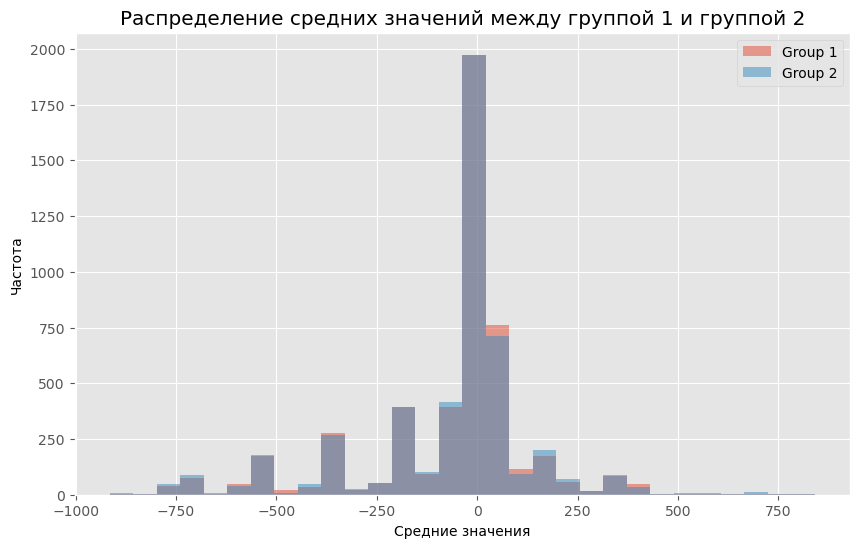

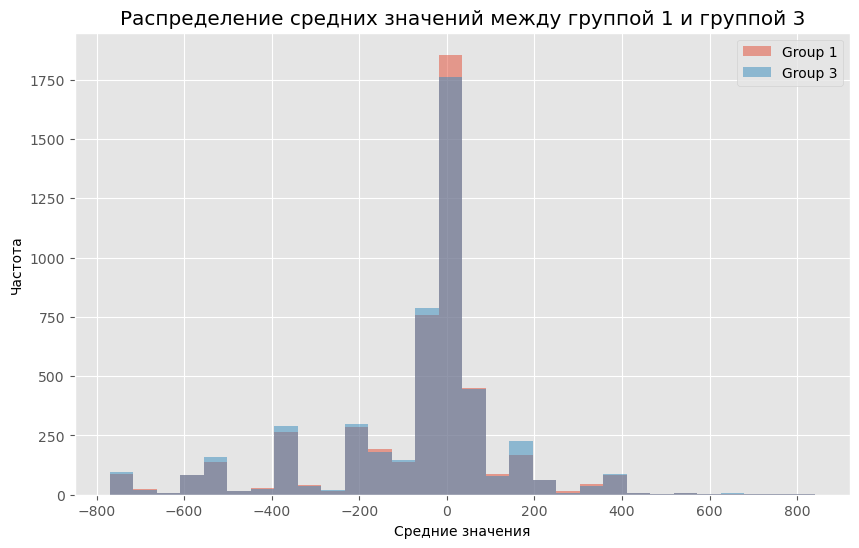

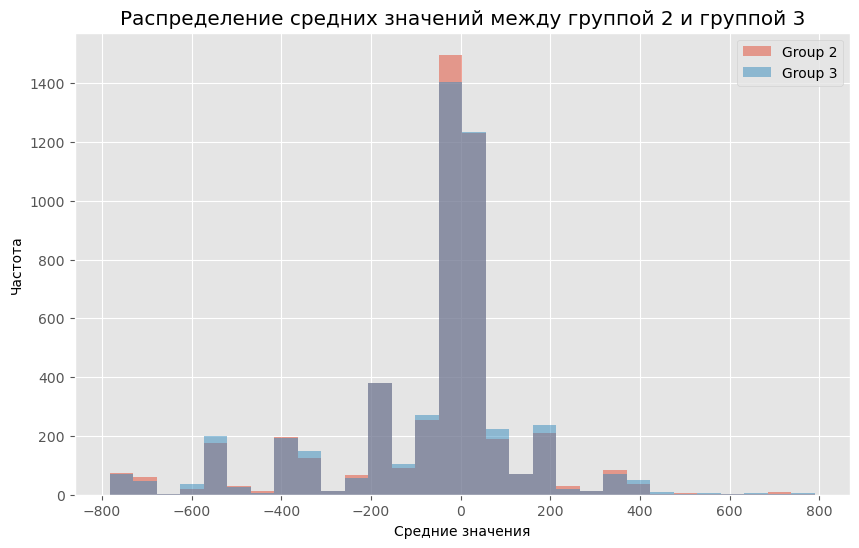

In [7]:
def plot_group_distributions(groups):
    bins_count = 30  
    alpha = 0.5  #прозрачность столбцов
    
    plt.style.use('ggplot')

    for i in range(len(groups)):
        for j in range(i+1, len(groups)):
            plt.figure(figsize=(10, 6))
            
            means_i = groups[i].mean(axis=1)
            means_j = groups[j].mean(axis=1)
            
            #объединяем средние значения двух групп для определения общих пределов на графике
            combined_means = np.hstack((means_i, means_j))
            
            #сделаем квантили, чтобы исключить экстремальные выбросы чтобы график был более читабельным и отмасштабируемым
            lower_bound = np.quantile(combined_means, 0.01)
            upper_bound = np.quantile(combined_means, 0.99)
            

            plt.hist(means_i, bins=bins_count, alpha=alpha, label=f'Group {i+1}', range=(lower_bound, upper_bound))
            plt.hist(means_j, bins=bins_count, alpha=alpha, label=f'Group {j+1}', range=(lower_bound, upper_bound))
            
            plt.title(f'Распределение средних значений между группой {i+1} и группой {j+1}')
            plt.xlabel('Средние значения')
            plt.ylabel('Частота')
            plt.legend()
            plt.show()


plot_group_distributions(groups)

# А теперь посмотрим на график групп, которые мы получили случайно

Группа 1: пользоваталей(строк) = 5000, среднее: -74.13729632426788
Группа 2: пользоваталей(строк) = 5000, среднее: -289.6451230658763
Группа 3: пользоваталей(строк) = 5000, среднее: 40.51701416415093


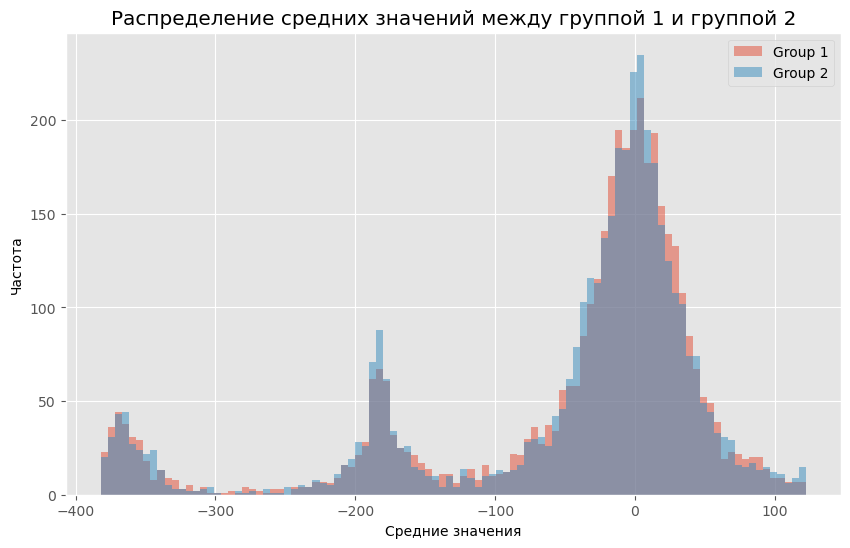

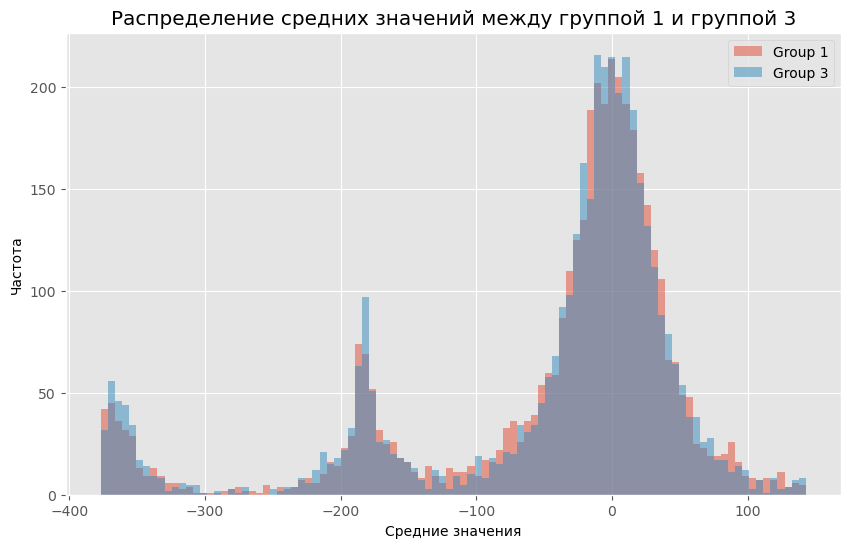

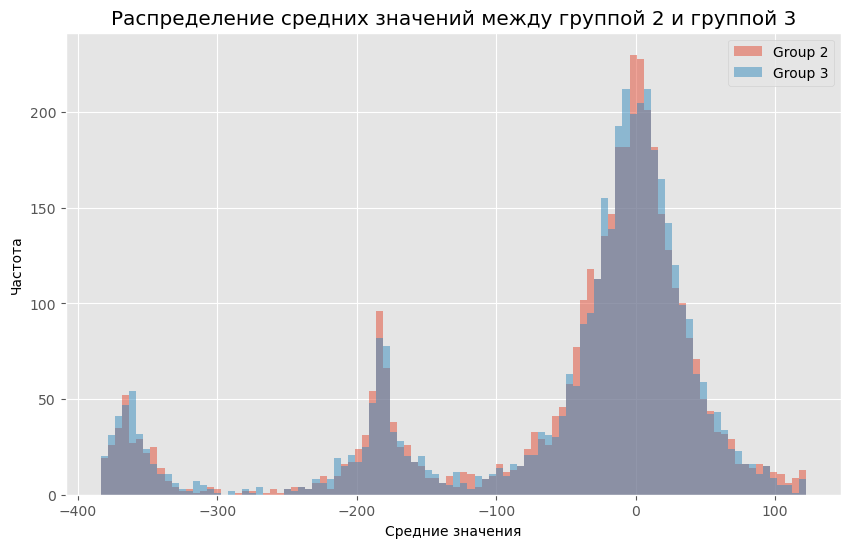

In [8]:
def plot_group_distributions(groups):
    bins_count = 100
    alpha = 0.5  #прозрачность столбцов
    
    plt.style.use('ggplot')

    for i in range(len(groups)):
        for j in range(i+1, len(groups)):
            plt.figure(figsize=(10, 6))
            
            means_i = groups[i].mean(axis=1)
            means_j = groups[j].mean(axis=1)
            
            #объединяем средние значения двух групп для определения общих пределов на графике
            combined_means = np.hstack((means_i, means_j))
            
            #сделаем квантили, чтобы исключить экстремальные выбросы чтобы график был более читабельным и отмасштабируемым
            lower_bound = np.quantile(combined_means, 0.1)
            upper_bound = np.quantile(combined_means, 0.9)
            

            plt.hist(means_i, bins=bins_count, alpha=alpha, label=f'Group {i+1}', range=(lower_bound, upper_bound))
            plt.hist(means_j, bins=bins_count, alpha=alpha, label=f'Group {j+1}', range=(lower_bound, upper_bound))
            
            plt.title(f'Распределение средних значений между группой {i+1} и группой {j+1}')
            plt.xlabel('Средние значения')
            plt.ylabel('Частота')
            plt.legend()
            plt.show()

#создадим 3 рандомных группы из датасета
groups = generate_groups(df, 3)

for i, group in enumerate(groups):
    print(f"Группа {i+1}: пользоваталей(строк) = {len(group)}, среднее: {group.mean().mean()}")
    
plot_group_distributions(groups)